STEP 1: Creating the Dataset
but Dataset class will need rle to binary conversion inside it. So lets prepare the rle_to_binaery def before moving to the Dataset class definition. 

In [1]:
import numpy as np

def rle_to_binary(rle, shape):
    # 1. Handle the NaN/Empty case
    if pd.isna(rle): 
        return np.zeros(shape, dtype=np.uint8)

    # 2. Your existing logic
    if isinstance(rle, str):
        rle = [int(x) for x in rle.split()]

    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    
    for i in range(0, len(rle), 2):
        start = rle[i] - 1
        length = rle[i+1]
        mask[start : start + length] = 1
        
    return mask.reshape(shape, order='C')


Ok now we are good to proceed with Dataset definition:

In [2]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path



class MadisonDataset(Dataset):
    def __init__(self, csv_file, img_dir, target_size=(256, 256)):
        self.df = pd.read_csv(csv_file)
        self.img_dir = Path (img_dir)
        self.target_size = target_size 
        self.ids = self.df['id'].unique()
        self.grouped = self.df.groupby('id')
        self.classes = ['large_bowel', 'small_bowel', 'stomach']


        #path mapping##
        self.path_map = {}
        for file_path in self.img_dir.rglob("*.png"):
            # 1. Get the 'day' folder name (e.g., 'case123_day0')
            day_folder = file_path.parent.parent.name 
            
            # 2. Get the 'slice' part (e.g., 'slice_0001')
            slice_part = file_path.stem.split('_')[0] + "_" + file_path.stem.split('_')[1]
            
            # 3. Construct the ID to match your CSV format: 'case123_day0_slice_0001'
            constructed_id = f"{day_folder}_{slice_part}"
            
            # Add to dictionary
            self.path_map[constructed_id] = str(file_path)


    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sample_id = self.ids[idx]
         
        # --- Look up the path in our pre-built dictionary ---
        img_path = self.path_map.get(sample_id)
        if img_path is None:
            raise FileNotFoundError(f"Could not find image for {sample_id}")
            
        img = Image.open(img_path).convert('L') # convert ('L) ensures that all images have 1 channel.
        # PIL.Image.size returns (width, height), so we swap for our function
        w, h = img.size 
        native_shape = (h, w)
        
        # 2. Resize image for the model
        img_resized = img.resize(self.target_size, resample=Image.BILINEAR)
        image_arr = np.array(img_resized, dtype=np.float32) / 603
        
        # 3. Decode masks using the native shape
        masks = []
        rows = self.grouped.get_group(sample_id)
        
        for cls in self.classes:
            row = rows[rows['class'] == cls]
            rle = row.iloc[0]['segmentation'] if len(row) > 0 else np.nan
            
            # Use our helper function with the dynamic native_shape
            mask = rle_to_binary(rle, native_shape)
            
            # Resize mask (Use NEAREST to preserve binary 0/1)
            mask_pil = Image.fromarray(mask)
            mask_resized = mask_pil.resize(self.target_size, resample=Image.NEAREST)
            masks.append(np.array(mask_resized))

        # 4. Final formatting
        mask_stack = np.stack(masks, axis=0) # (3, 256, 256)
        
        return (torch.from_numpy(image_arr).float().unsqueeze(0), 
                torch.from_numpy(mask_stack).float())


STEP 2: Splitting

just keep in mind:

The Problem: Data Leakage
In your dataset, one patient (one case_id) has many slices.

The “Leak”: If you use random_split blindly, “Case 123 - Slice 5” might end up in the training set, while “Case 123 - Slice 6” ends up in the validation set.
The Result: Since the slices are almost identical, your model will “memorize” the patient’s anatomy rather than learning to segment organs. Your validation score will look amazing, but when you test on a new patient, your model will fail completely.
The Correct Way (The “Group-Aware” Split)
To keep using PyTorch’s splitting utilities (like Subset), you need to perform the split based on unique patient IDs first, then map those back to indices.

Here is the standard, professional approach for medical imaging:

In [34]:
from sklearn.model_selection import train_test_split

# 1. Define the function
def get_case_prefix(full_id):
    return full_id.split('_')[0]

full_df = pd.read_csv("/Users/ali/Desktop/madison/train.csv")
# 2. Create an empty list to store your new values
case_ids_list = []



# 2. Get the unique case names from your 'id' column
# Assuming your dataframe is named 'full_df'
all_case_ids = full_df['id'].apply(get_case_prefix).unique()

# 3. Split those unique case names into 80% train and 20% val
train_ids, val_ids = train_test_split(all_case_ids, test_size=0.2, random_state=42)

# 4. Create the final train and validation dataframes
train_df = full_df[full_df['id'].apply(get_case_prefix).isin(train_ids)].copy()
val_df = full_df[full_df['id'].apply(get_case_prefix).isin(val_ids)].copy()



####### Creating Mini-Dataset ######## (If you want to have the whole dataset, omit this section) 
mini_size = 100
train_df = train_df.sample(frac=1, random_state=42).head(mini_size).copy()
val_df = val_df.sample(frac=1, random_state=42).head(mini_size).copy()
###### End of Mini-Dataset creation ######


train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)

In [35]:
full_df.describe, train_df.describe, val_df.describe

(<bound method NDFrame.describe of                               id        class segmentation
 0       case123_day20_slice_0001  large_bowel          NaN
 1       case123_day20_slice_0001  small_bowel          NaN
 2       case123_day20_slice_0001      stomach          NaN
 3       case123_day20_slice_0002  large_bowel          NaN
 4       case123_day20_slice_0002  small_bowel          NaN
 ...                          ...          ...          ...
 115483    case30_day0_slice_0143  small_bowel          NaN
 115484    case30_day0_slice_0143      stomach          NaN
 115485    case30_day0_slice_0144  large_bowel          NaN
 115486    case30_day0_slice_0144  small_bowel          NaN
 115487    case30_day0_slice_0144      stomach          NaN
 
 [115488 rows x 3 columns]>,
 <bound method NDFrame.describe of                              id        class  \
 84336   case36_day10_slice_0065  large_bowel   
 32406  case134_day22_slice_0035  large_bowel   
 37633   case90_day29_slice_0049  

In [36]:

train_dataset = MadisonDataset(csv_file='/Users/ali/Desktop/train_split.csv' , img_dir= '/Users/ali/Desktop/madison/train')
val_dataset = MadisonDataset(csv_file= '/Users/ali/Desktop/val_split.csv', img_dir= '/Users/ali/Desktop/madison/train')

STEP3: DataLoader definition

In [37]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Sanity check--->

In [ ]:
train_iter = iter(train_loader)

In [38]:
images, labels = next(train_iter)
print(f"Batch: {images.shape}, {labels.shape}")

Batch: torch.Size([32, 1, 256, 256]), torch.Size([32, 3, 256, 256])


STEP 4: Model

In [39]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name= 'resnet34', 
    encoder_weights='imagenet',
    in_channels=1,       # MUST be 1 because your images are grayscale
    classes=3,           # This is correct (Stomach, Small Bowel, Large Bowel)
    activation=None      # MUST be None to output raw logits for BCEWithLogitsLoss
)


device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = model.to(device)

Choose the LossFunction and Optimizer

In [40]:
loss_fn = smp.losses.DiceLoss(mode='multilabel')
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

STEP 5: Trainig and Validation

In [45]:
from tqdm import tqdm
import matplotlib.pyplot as plt

def train (train_loader, model, loss_fn, optimizer, train_dataset):
    model.train ()
    loss_sum = 0
    for x_batch, y_batch in tqdm (train_loader):
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float()
        y_predicted = model (x_batch)
        loss = loss_fn (y_predicted, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_sum += (loss.item() * len (x_batch))
    mean_loss_train = loss_sum / len (train_dataset)
    return mean_loss_train   


def validation (val_loader, model, loss_fn, val_dataset):
    with torch.no_grad():
        loss_sum2 = 0
        for x_batch_val, y_batch_val in val_loader:
            x_batch_val = x_batch_val.to(device).float() 
            y_batch_val = y_batch_val.to(device).float()
            y_predicted_val = model (x_batch_val)
            loss_val = loss_fn (y_predicted_val, y_batch_val)
            loss_sum2 += loss_val.item() * len (x_batch_val)
        mean_loss_val = loss_sum2 / len (val_dataset)
        return mean_loss_val 
    
def learning_curve_plotter (list1, list2):
    plt.plot (list1, label='train_set')
    plt.plot (list2, label='val_set')
    plt.xlabel ('epoch')
    plt.ylabel ('loss')
    plt.legend()
    plt.show()


def operator (train_loader, val_loader, model, loss_fn, optimizer, train_dataset, val_dataset, n_epoch):
    list1 = []
    list2 = []
    best_loss_val = torch.inf
    for epoch in range (n_epoch):
        mean_loss_train = train (train_loader, model, loss_fn, optimizer, train_dataset)
        mean_loss_val = validation (val_loader, model, loss_fn, val_dataset)
        list1.append (mean_loss_train)
        list2.append (mean_loss_val)
        print (f'Epoch {epoch+1}/{n_epoch}--> train_loss : {mean_loss_train}, validation loss : {mean_loss_val}')
        torch.save (model, f'/Users/ali/Desktop/Model.No {epoch}')
        if mean_loss_val < best_loss_val:
            torch.save (model, '/Users/ali/Desktop/bestmodel')
            best_loss_val = mean_loss_val
            print ('model saved!')
    learning_curve_plotter (list1, list2)

Using MPS (Apple GPU)


100%|██████████| 4/4 [00:02<00:00,  1.54it/s]


Epoch 1/10--> train_loss : 0.9649570333957672, validation loss : 0.9811521530151367
model saved!


100%|██████████| 4/4 [00:02<00:00,  1.57it/s]


Epoch 2/10--> train_loss : 0.9909964823722839, validation loss : 0.9807409119606018
model saved!


...

Epoch 8/10--> train_loss : 0.9728031945228577, validation loss : 0.9782677721977234
model saved!


100%|██████████| 4/4 [00:02<00:00,  1.54it/s]


Epoch 9/10--> train_loss : 0.9713174223899841, validation loss : 0.9774564814567566
model saved!


100%|██████████| 4/4 [00:02<00:00,  1.54it/s]


Epoch 10/10--> train_loss : 0.9698174643516541, validation loss : 0.9764593911170959
model saved!


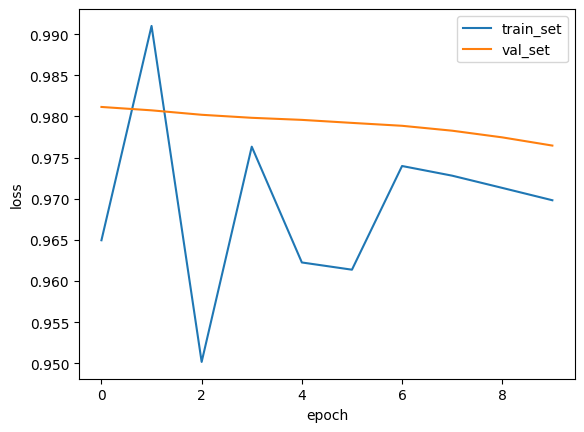

In [47]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")


operator (train_loader=train_loader, 
          val_loader=val_loader, 
          model=model.to(device), 
          loss_fn=loss_fn, 
          optimizer=optimizer, 
          train_dataset=train_dataset, 
          val_dataset=val_dataset, 
          n_epoch=10)
